# 1. Importación

Carga de las librerías, del modelo final guardado por `03_model_training.ipynb` (`models/price_model.pkl`, `models/model_metadata.json`) y del test (`data/processed/listings_test.csv`). Este notebook no reentrena nada, parte de lo que ya quedó guardado.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
final_pipeline = joblib.load("/Users/yagocoll/Documents/Master/Airbnb/models/price_model.pkl")

with open("/Users/yagocoll/Documents/Master/Airbnb/models/model_metadata.json") as f:
    metadata = json.load(f)

test_df = pd.read_csv("/Users/yagocoll/Documents/Master/Airbnb/data/processed/listings_test.csv")
metadata["test_metrics"]

{'modelo': 'Hist Gradient Boosting (final)',
 'RMSE': 140.95513459919064,
 'MAE': 50.820143003717554,
 'R2': 0.7908171969714554,
 'MAPE': 20.558957975340856}

## 2. Reconstruir predicciones

Mismos `feature_cols`/`target` que en el entrenamiento (guardados en `metadata`, no hay que volver a decidirlos a mano), para tener `y_test` y las predicciones disponibles para todo el análisis que sigue.

### 2.1 X e y de test

`metadata["feature_cols"]` ya tiene la lista exacta de columnas que espera el modelo, en el mismo orden y con el mismo criterio (identificadores y columnas de fuga ya excluidos desde `03_model_training.ipynb`). Las booleanas se convierten a `int`, igual que en el entrenamiento.

In [3]:
feature_cols = metadata["feature_cols"]
target_col = metadata["target"]

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

bool_cols = X_test.select_dtypes(include="bool").columns
X_test[bool_cols] = X_test[bool_cols].astype(int)

X_test.shape

(2652, 71)

### 2.2 Función `evaluate`

No existe todavía en este notebook (es nuevo, no hereda nada de `03_model_training.ipynb`). Se define igual que en los dos notebooks anteriores, para mantener las mismas métricas en los tres.

In [4]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"modelo": name, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

### 2.3 Predecir

El modelo predice en escala `log1p(price)`; se deshace con `expm1` antes de evaluar nada.

In [5]:
pred = np.expm1(final_pipeline.predict(X_test))
residuals = pred - y_test.values

evaluate(y_test, pred, "Hist Gradient Boosting")

{'modelo': 'Hist Gradient Boosting',
 'RMSE': np.float64(140.95513459919064),
 'MAE': 50.820143003717554,
 'R2': 0.7908171969714554,
 'MAPE': np.float64(20.558957975340856)}

Coincide exactamente con `metadata["test_metrics"]` (RMSE=140.96€, MAE=50.82€, R²=0.79, MAPE=20.56%): el modelo cargado predice igual que cuando se guardó, así que se puede seguir con el análisis de errores con confianza en que no hay ninguna discrepancia por el camino.

Nota sobre esta versión del modelo: incluye 5 features nuevas de `02D_fe_listings_full.ipynb` (`has_ac`, `has_pool`, `has_dishwasher`, `n_amenities`, `n_nearby_150m`). El MAE apenas cambia frente a la versión sin ellas (50.29€ → 50.82€, prácticamente igual, incluso un pelín peor) — coherente con lo que ya se había explorado de forma más rigurosa (CV con búsqueda de hiperparámetros) antes de decidir incluirlas: aportan poco o nada de mejora medible, pero se incorporan igualmente por decisión de producto, no porque el dato diga que hace falta.

## 3. Predicción vs. realidad

Scatter de precio predicho contra precio real, y distribución de los residuos (`predicho - real`). El objetivo es detectar si el modelo tiene algún sesgo sistemático (p. ej. que subestime siempre los precios altos), algo que un único número como el R² no muestra.

### 3.1 Predicho vs. real

Cada punto es un anuncio del test; la línea roja discontinua es "predicción perfecta" (`predicho = real`). Los puntos por debajo de la línea son subestimaciones, los de encima sobreestimaciones.

(0.0, 2000.0)

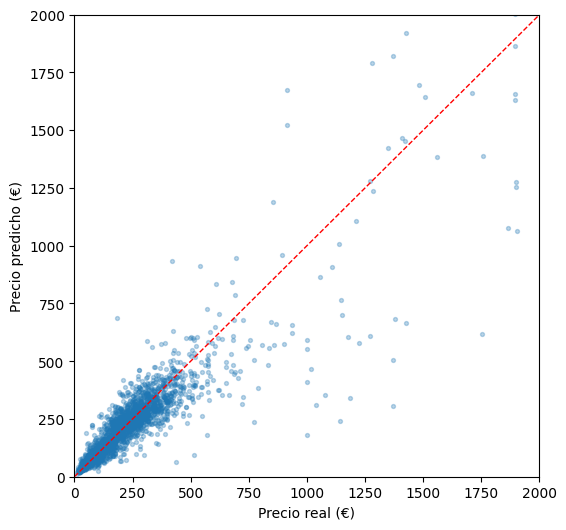

In [6]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, s=8, alpha=0.3)
lims = [0, 2000]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlabel("Precio real (€)")
plt.ylabel("Precio predicho (€)")
plt.xlim(lims)
plt.ylim(lims)

Para precios bajos y medios (hasta unos 500-750€) los puntos siguen bastante de cerca la diagonal. A partir de ahí, cada vez más puntos caen claramente por debajo: **el modelo tiende a subestimar los anuncios más caros**.

### 3.2 Distribución de los residuos

`residuals = predicho - real`. Un residuo negativo es una subestimación.

Media: -11.930565023642433
Mediana: 1.023401333914924


(-500.0, 500.0)

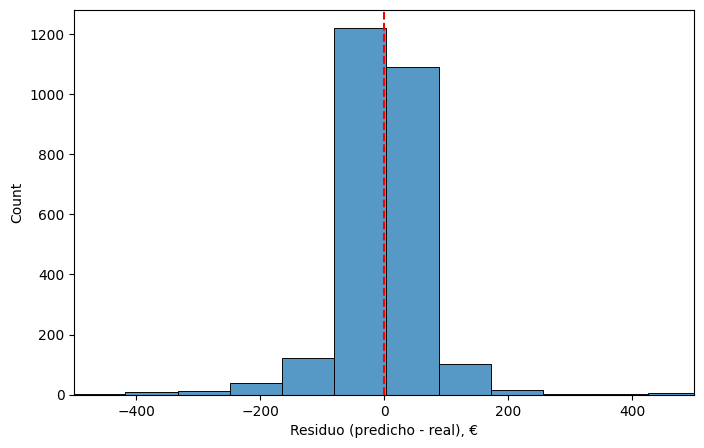

In [7]:
print("Media:", residuals.mean())
print("Mediana:", np.median(residuals))

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=60)
plt.axvline(0, color="r", linestyle="--")
plt.xlabel("Residuo (predicho - real), €")
plt.xlim(-500, 500)

La mediana del residuo es prácticamente 0 (1.02€): para la mitad de los anuncios el modelo acierta casi exacto o incluso se queda un poco corto o largo por igual. Pero la **media es -11.93€**, bastante más negativa. Es la misma lección de la sección 4 del baseline: la media y la mediana cuentan historias distintas cuando hay una cola de errores grandes en una sola dirección. Aquí esa cola son las subestimaciones en los anuncios caros que ya se veían en el scatter.

### 3.3 ¿El sesgo depende del precio?

Se comprueba con dos vistas: un scatter de residuo contra precio real, y la media del residuo por quintiles de precio.

(0.0, 2000.0)

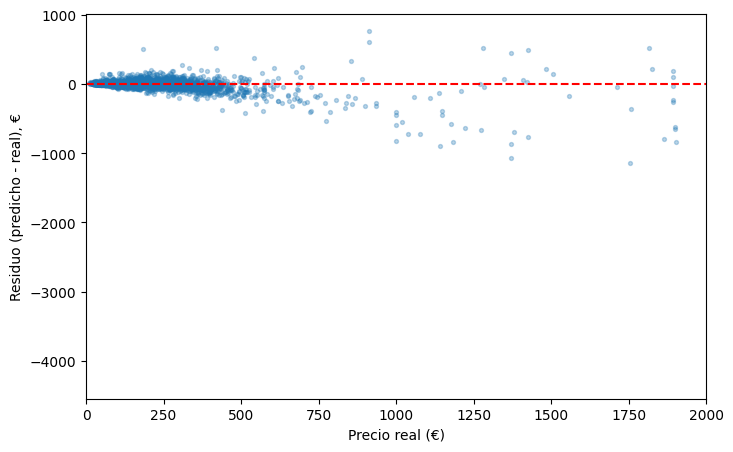

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, residuals, s=8, alpha=0.3)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Precio real (€)")
plt.ylabel("Residuo (predicho - real), €")
plt.xlim(0, 2000)

In [9]:
price_quintile = pd.qcut(y_test, 5)
pd.DataFrame({"residual": residuals}).groupby(price_quintile, observed=True)["residual"].agg(["mean", "median", "count"])

,mean,median,count
price,,,
"(10.949, 75.698]",8.337864,4.445241,531
"(75.698, 138.26]",4.604301,1.761244,530
"(138.26, 218.0]",12.729403,6.657990,531
"(218.0, 312.4]",2.672693,-0.246505,529
"(312.4, 4463.0]",-87.910944,-52.852457,531


Confirmado con números: en los cuatro quintiles de precio más bajos, el residuo medio está entre +2.7€ y +12.7€, prácticamente sin sesgo. En el quintil más caro (por encima de 312€) el residuo medio es **-87.9€** (mediana -52.9€) — el modelo subestima sistemáticamente los anuncios más caros, y de forma bastante más severa que el error "típico" que sugieren el MAE o el R² globales.

Es un patrón esperable dado cómo se entrenó el modelo: al optimizar sobre `log1p(price)`, un error relativo pequeño en la cola alta (donde `log1p` comprime mucho los valores) se traduce en un error absoluto grande al deshacer el logaritmo. El modelo global (R²=0.79, MAE=51€) sigue siendo bueno en conjunto, pero para un caso de uso donde importen especialmente los anuncios de precio alto, este sesgo sistemático es una limitación real a tener en cuenta, no solo una anécdota de un par de casos sueltos.

## 4. Errores por segmento

MAE/RMSE desglosados por `room_type`, por distrito y por rango de precio, para ver si el modelo falla más en algún grupo concreto en vez de fallar de forma pareja en todo el dataset.

### 4.1 Por `room_type`

Desde `02D_fe_listings_full.ipynb`, `room_type` quedó como 4 columnas one-hot (`room_type_Entire home/apt`, etc.), no como una única columna categórica. Se reconstruye con `idxmax` antes de agrupar.

In [10]:
room_type_cols = [c for c in feature_cols if c.startswith("room_type_")]
room_type_series = X_test[room_type_cols].idxmax(axis=1).str.replace("room_type_", "", regex=False)

rows = []
for rt in room_type_series.unique():
    mask = (room_type_series == rt).values
    scores = evaluate(y_test[mask], pred[mask], rt)
    scores["n"] = mask.sum()
    rows.append(scores)

pd.DataFrame(rows).set_index("modelo").round(2)

,RMSE,MAE,R2,MAPE,n
modelo,,,,,
Entire home/apt,155.74,58.95,0.78,20.34,2022
Private room,77.26,24.56,0.72,21.26,599
Shared room,48.48,20.34,0.61,23.53,19
Hotel room,48.23,40.37,0.83,16.72,12


`Entire home/apt` (2022 filas, la mayoría del test) tiene el RMSE/MAE más altos en euros, pero es esperable: es la categoría con precios más altos y más dispersos, así que sus errores absolutos también lo son. `Private room` tiene errores mucho más bajos en euros (MAE=25€). `Shared room` (19 filas) y `Hotel room` (12 filas) tienen muestras demasiado pequeñas para sacar conclusiones firmes de su R² (0.61 y 0.83 respectivamente) — con tan pocas filas, estos números son sensibles a qué anuncios concretos caen en el test, como ya se vio al estratificar el split en `03_model_baseline.ipynb` para que al menos su proporción sea representativa.

### 4.2 Por distrito

In [11]:
district_cols = [c for c in feature_cols if c.startswith("district_")]
district_series = X_test[district_cols].idxmax(axis=1).str.replace("district_", "", regex=False)

rows = []
for d in district_series.unique():
    mask = (district_series == d).values
    scores = evaluate(y_test[mask], pred[mask], d)
    scores["n"] = mask.sum()
    rows.append(scores)

pd.DataFrame(rows).set_index("modelo").round(2).sort_values("n", ascending=False)

,RMSE,MAE,R2,MAPE,n
modelo,,,,,
Eixample,191.14,66.34,0.75,19.15,1052
Ciutat Vella,94.31,39.00,0.87,22.92,547
Sants-Montjuïc,129.45,48.85,0.87,21.32,246
Gràcia,68.20,40.57,0.66,19.73,244
Sant Martí,87.63,44.63,0.65,21.75,234
Sarrià-Sant Gervasi,50.57,31.33,0.83,18.78,158
Horta-Guinardó,88.13,38.56,0.87,21.74,57
Les Corts,163.04,53.88,0.51,22.23,53
Sant Andreu,36.14,20.21,0.78,20.25,34


El R² por distrito sigue sin depender de forma limpia del tamaño de muestra: `Ciutat Vella` (547 filas) y `Sants-Montjuïc` (246) y `Horta-Guinardó` (57, muestra pequeña) rondan 0.87, mientras que `Gràcia` (244 filas) y `Sant Martí` (234 filas) — ambos con muestra igual de grande — bajan a 0.65-0.66, y `Eixample` (1052 filas, el distrito con más datos de todos) se queda en 0.75. El peor de todos es `Les Corts` (0.51), con solo 53 filas.

Esto es distinto de lo que parecía con el split anterior (con fuga y sin estratificar), donde los distritos pequeños salían sistemáticamente peor. Con el split corregido, el tamaño de muestra por distrito no explica por sí solo el R²: importa más qué anuncios concretos caen en el test de cada zona. En cualquier caso, en euros (MAE) el rango sigue siendo razonable en todos los distritos (20-66€), así que esta variabilidad de R² no significa errores absolutos disparatados, solo que la varianza explicada depende de qué tan dispersos sean los precios dentro de cada distrito en el test.

### 4.3 Por rango de precio

Se completa lo que ya se vio en la sección 3.3 (solo con la media del residuo) con las métricas completas por quintil.

In [12]:
price_quintile = pd.qcut(y_test, 5)

rows = []
for q in price_quintile.cat.categories:
    mask = (price_quintile == q).values
    scores = evaluate(y_test[mask].values, pred[mask], str(q))
    scores["n"] = mask.sum()
    rows.append(scores)

pd.DataFrame(rows).set_index("modelo").round(2)

,RMSE,MAE,R2,MAPE,n
modelo,,,,,
"(10.949, 75.698]",20.07,12.10,-0.52,26.41,531
"(75.698, 138.26]",29.79,19.92,-2.00,18.92,530
"(138.26, 218.0]",53.97,37.56,-4.30,21.17,531
"(218.0, 312.4]",54.48,40.53,-3.17,15.43,529
"(312.4, 4463.0]",303.43,143.89,0.68,20.84,531


El MAE crece de forma clara con el precio (12€ → 20€ → 38€ → 41€ → 144€ en el quintil más caro), coherente con la sección 3. El R² por quintil, en cambio, **no es una métrica útil aquí**: sale negativo en varios quintiles intermedios, no porque el modelo sea malo, sino porque al cortar por rangos de precio la variabilidad *dentro* de cada quintil es pequeña por construcción, y el R² depende de esa variabilidad para tener sentido. Para segmentar por precio conviene mirar MAE/RMSE en euros, no R².

## 5. Los peores casos

Los anuncios con mayor error absoluto, inspeccionados uno a uno: ¿son los Group Flats de la EDA? ¿anuncios con algún dato raro? ¿o errores sin patrón aparente?

### 5.1 Los 15 mayores errores absolutos

In [13]:
worst_idx = np.argsort(-np.abs(residuals))[:15]

cols_show = ["id", "price", "bedrooms", "accommodates", "minimum_nights", "bathrooms"]
worst = test_df.iloc[worst_idx][cols_show].copy()
worst["pred"] = pred[worst_idx]
worst["residual"] = residuals[worst_idx]
worst

,id,price,bedrooms,accommodates,minimum_nights,bathrooms,pred,residual
1255,909087702399642381,4463.00,2.0,4,1.0,1.0,170.364340,-4292.635660
2521,1692703058477448525,2034.00,3.0,5,1.0,2.0,436.621407,-1597.378593
1619,1178140193042111987,3504.00,9.0,16,1.0,5.0,2063.331455,-1440.668545
1820,1278968347892035134,2602.00,8.0,16,1.0,4.0,1281.341282,-1320.658718
1560,1569007586819864216,3983.00,12.0,16,1.0,6.0,2841.942398,-1141.057602
2461,51342550,1754.29,1.0,8,5.0,5.0,618.003685,-1136.286315
2330,1183146635229347122,1369.41,2.0,4,1.0,1.0,305.158264,-1064.251736
2182,1675517721211179327,1140.50,1.0,2,2.0,1.0,241.863527,-898.636473
1463,1712461869229272143,1369.41,3.0,6,2.0,2.0,505.648104,-863.761896
115,1548178014374619383,1183.88,4.0,5,1.0,1.0,342.362970,-841.517030


### 5.2 El patrón principal: los Group Flats (y una excepción notable)

14 de los 15 son subestimaciones, y la mayoría tiene `bedrooms` entre 3 y 14 y `accommodates` entre 4 y 16 (el máximo de la plataforma). Varios son los "Group Flats" que ya aparecieron en la sección 8 de la EDA de `01D_eda_listings_full.ipynb`: pisos para grupos grandes en el Eixample, con precios de miles de euros. Confirma lo que ya se veía en la sección 3 y 4: el modelo se queda corto en la cola alta de precio, y estos son los casos concretos donde más se nota.

Hay una excepción: el id `34708362` (8 dormitorios, 16 huéspedes, 913€) es un Group Flat que el modelo **sobreestima** en +761€ — el único residuo positivo de los 15. No contradice el patrón general (que sigue siendo subestimar la cola alta), pero confirma que no es un sesgo absoluto e infalible: dentro de la categoría "piso grande" también hay variación real de precio que el modelo a veces sobreestima.

El error más grande de todos, con mucha diferencia, no es un Group Flat: es el id `909087702399642381` (2 dormitorios, 4 huéspedes, 4463€, subestimado en -4293€). Se investiga aparte en la sección 5.3, junto con otros casos de precio pequeño-anuncio/precio-disparatado.

### 5.3 Un patrón distinto: anuncios pequeños con precio disparatado

Tres casos no encajan con el patrón de Group Flats: `bedrooms` 1-2, `accommodates` 2-4 (nada que ver con un piso para grupos grandes), pero precios de 1140-4463€ — incluido el error más grande de todo el test. Se investigan por separado.

In [14]:
anomaly_ids = [1183146635229347122, 1675517721211179327, 909087702399642381]
cols_anomaly = [
    "id", "price", "bedrooms", "accommodates", "bathrooms", "minimum_nights",
    "has_license", "host_is_superhost", "review_scores_rating", "number_of_reviews",
]
test_df[test_df["id"].isin(anomaly_ids)][cols_anomaly]

,id,price,bedrooms,accommodates,bathrooms,minimum_nights,has_license,host_is_superhost,review_scores_rating,number_of_reviews
1255,909087702399642381,4463.00,2.0,4,1.0,1.0,False,False,1.0,1
2182,1675517721211179327,1140.50,1.0,2,1.0,2.0,True,False,5.0,1
2330,1183146635229347122,1369.41,2.0,4,1.0,1.0,True,False,NaN,0


Los tres tienen **0 o 1 reviews** (y el caso más extremo, `909087702399642381`, tiene exactamente 1 review con `review_scores_rating=1.0`, la peor nota posible), pese a tener licencia y ser anuncios normales por lo demás (2-4 huéspedes, 1-2 dormitorios). Un piso de 2 dormitorios a 4463€/noche no es un precio de mercado creíble para ese tamaño, y la falta casi total de reviews (o la única reseña siendo pésima) encaja con una explicación habitual en plataformas de alquiler: un host pone un precio disparatadamente alto para que en la práctica nadie reserve, sin llegar a desactivar el anuncio del todo (a veces para "cerrarlo" temporalmente, o tras una mala experiencia). Si es así, el modelo no está fallando por no entender el alojamiento, está fallando porque ese número no refleja un precio real de mercado. No hay forma de confirmarlo con los datos disponibles, pero es una hipótesis más plausible que asumir que el modelo simplemente no sabe valorar apartamentos pequeños.

En conjunto, los peores errores del modelo tienen dos causas distintas: la cola alta de precio genuina (Group Flats, donde el modelo subestima de forma sistemática) y un puñado de precios que probablemente no son de mercado real. Ninguna de las dos se soluciona con más ajuste de hiperparámetros; la primera necesitaría tratar la cola alta de otra forma (p. ej. un modelo separado para grupos grandes, o pesos distintos en el entrenamiento), y la segunda necesitaría poder identificar y filtrar precios no realistas antes de entrenar.

## 6. Nota sobre la fuga de `neighbourhood_price_encoded` (ya corregida)

Esta sección investigaba originalmente si la fuga de `neighbourhood_price_encoded` (calculada en `02D_fe_listings_full.ipynb` con todo el dataset, no solo train) importaba de verdad antes de decidir si corregirla. La comprobación de entonces encontró un impacto real pero pequeño (R² 0.86→0.84, MAE 52€→54€) y dejó como decisión pendiente si merecía la pena regenerar el pipeline.

Esa decisión ya se tomó: `02D_fe_listings_full.ipynb` ahora mantiene `neighbourhood_cleansed` hasta después del split, y `03_model_baseline.ipynb` recalcula el encoding usando solo train (sección 3.1bis) antes de guardar `listings_train.csv`/`listings_test.csv`. El modelo cargado al principio de este notebook ya viene entrenado con la versión corregida — `metadata["test_metrics"]` de la sección 1 son los números honestos, no hay nada que recalcular aquí. Se elimina la investigación original (ya cumplió su función) y se deja esta nota como referencia de por qué la sección 6 es más corta de lo que era.

## 7. Conclusiones

Resumen de si el modelo se comporta de forma consistente en todo el dataset o tiene puntos débiles claros, y si la fuga pendiente resultó relevante o no.

### Veredicto general

El modelo cargado reproduce exactamente las métricas con las que se guardó, así que todo el análisis siguiente parte de una base fiable. En conjunto, **es un modelo sólido para la mayoría de anuncios** (precio bajo y medio), pero tiene puntos débiles claros y ya identificados, no solo un número de R² global. Esta versión del modelo ya no arrastra la fuga de `neighbourhood_price_encoded` ni el riesgo de un split no representativo por `room_type` (ambos corregidos en `02D_fe_listings_full.ipynb`/`03_model_baseline.ipynb`), así que las métricas de aquí en adelante son honestas de principio a fin. Incluye además 5 features nuevas de amenities y densidad de anuncios cercanos (sección 1) que, en la práctica, no cambian el resultado de forma medible — se mantienen por decisión de producto, no porque mejoren el modelo.

### Lo que funciona bien

- Buen ajuste en los cuatro quintiles de precio más bajos (sesgo casi nulo, entre +2.7€ y +12.7€ de media).
- MAE contenido (20-66€) en todos los distritos y tipos de alojamiento, incluidos los de poca muestra.
- Sin señales de sobreajuste (train y test se comportan de forma consistente, ya visto en `03_model_training.ipynb`).

### Limitaciones identificadas

1. **Subestima sistemáticamente los anuncios más caros**: residuo medio de -87.9€ en el quintil superior de precio, frente a un sesgo casi nulo en el resto. Los "Group Flats" (pisos para grupos grandes) concentran la mayoría de los peores errores, aunque no todos: también hay una excepción sobreestimada y, sobre todo, un puñado de anuncios pequeños con precio no realista (ver limitación 3).
2. **El R² por distrito no depende de forma limpia del tamaño de muestra**: distritos grandes como `Gràcia`/`Sant Martí` (0.65-0.66) no van necesariamente mejor que distritos pequeños como `Horta-Guinardó` (0.87). El MAE en euros se mantiene razonable en todos los casos; es la varianza explicada la que varía según qué anuncios concretos caen en el test de cada zona.
3. **Un puñado de precios que probablemente no son de mercado real**: anuncios pequeños con precio disparatado y 0-1 reviews (uno con una única reseña de nota mínima), posibles "precios de cierre". El modelo no puede aprender a predecir bien algo que no responde a una lógica de mercado normal — y es, con diferencia, el error más grande de todo el test.

### Recomendaciones

**De cara a un producto real** (recordando la conversación inicial sobre el caso de uso): dar un **rango de precio, no un número único**, y sobre todo avisar explícitamente cuando el input se parezca a un caso de baja confianza: `bedrooms`/`accommodates` muy altos (zona de los Group Flats). Ahí el modelo es objetivamente menos fiable, y un usuario debería saberlo.

**De cara a mejorar el modelo, no aplicado aquí**:
- Tratar la cola alta de precio de forma distinta: un modelo separado para alojamientos grandes, o dar más peso a esos casos durante el entrenamiento.
- Explorar si se pueden filtrar o marcar los anuncios con precio sin actividad real (0-1 reviews y precio extremo) antes de entrenar, en vez de dejar que el modelo intente aprender de ruido.